In [161]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Bibliotecas especializadas
# import missingno as msno
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
# import category_encoders as ce
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print(" Bibliotecas importadas!")

 Bibliotecas importadas!


Carregamento e Exploração de Dados

In [162]:
from pathlib import Path
import pandas as pd
import os

# Caminho da pasta onde estão os CSVs
path = Path('../../data/Airbnb Prices in European Cities/raw')

list_of_dfs = []

for file in os.listdir(path):
    if file.endswith(".csv"):
        
        file_path = path / file
        print(f"📂 Lendo arquivo: {file_path}")

        # ✅ Lê o CSV ORIGINAL, sem modificar nada
        df_temp = pd.read_csv(file_path)

        list_of_dfs.append(df_temp)

        print(f"✔ Lido: {file} | Linhas: {len(df_temp)}")

# ✅ Junta tudo em um único DataFrame
df = pd.concat(list_of_dfs, ignore_index=True)

print("\n--------------------------------------------")
print("📊 Todos os dados foram combinados em `df` (VERSÃO ORIGINAL PARA EDA)")
print(f"Total de linhas: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")


📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/rome_weekdays.csv
✔ Lido: rome_weekdays.csv | Linhas: 4492
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/athens_weekends.csv
✔ Lido: athens_weekends.csv | Linhas: 2627
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/amsterdam_weekends.csv
✔ Lido: amsterdam_weekends.csv | Linhas: 977
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/budapest_weekdays.csv
✔ Lido: budapest_weekdays.csv | Linhas: 2074
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/rome_weekends.csv
✔ Lido: rome_weekends.csv | Linhas: 4535
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/budapest_weekends.csv
✔ Lido: budapest_weekends.csv | Linhas: 1948
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/barcelona_weekdays.csv
✔ Lido: barcelona_weekdays.csv | Linhas: 1555
📂 Lendo arquivo: ../../data/Airbnb Prices in European Cities/raw/lisbon_weekdays.csv
✔ Lido: 

In [163]:
cols_lfs = [
    'version https://git-lfs.github.com/spec/v1',
    'oid sha256',
    'size'
]

df = df.drop(columns=[c for c in cols_lfs if c in df.columns])


Análise Exploratória Estrutural

In [164]:
# 1. Informações básicas do dataset
print("\n1️⃣ INFORMAÇÕES GERAIS:")
print(f"Shape: {df.shape}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1️⃣ INFORMAÇÕES GERAIS:
Shape: (50425, 20)
Memória: 14.30 MB


In [165]:
# 2. Tipos de dados
print("\n2️⃣ TIPOS DE DADOS:")
print(df.dtypes)


2️⃣ TIPOS DE DADOS:
Unnamed: 0                    float64
realSum                       float64
room_type                      object
room_shared                    object
room_private                   object
person_capacity               float64
host_is_superhost              object
multi                         float64
biz                           float64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                      float64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object


In [166]:
# 3. Primeiras linhas
print("\n3️⃣ PRIMEIRAS 5 LINHAS:")
display(df.head())


3️⃣ PRIMEIRAS 5 LINHAS:


,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0.0,156.874664,Private room,False,True,2.0,True,1.0,0.0,10.0,95.0,1.0,2.978468,1.595733,281.163932,6.230648,697.727246,15.191486,12.48654,41.92498
1,1.0,172.772543,Private room,False,True,2.0,False,1.0,0.0,9.0,80.0,1.0,0.935371,0.649269,482.707193,10.696887,1251.524333,27.249208,12.49627,41.90801
2,2.0,277.745307,Entire home/apt,False,False,4.0,False,0.0,1.0,9.0,90.0,1.0,2.203025,0.494697,691.708998,15.328408,1625.897266,35.400361,12.47700,41.90700
3,3.0,444.906834,Entire home/apt,False,False,6.0,False,1.0,0.0,9.0,92.0,2.0,2.703010,1.295153,805.592641,17.852092,2035.819533,44.325522,12.46969,41.90019
4,4.0,131.391298,Private room,False,True,3.0,False,1.0,0.0,9.0,91.0,1.0,1.295968,0.867455,317.076369,7.026475,836.622814,18.215634,12.51544,41.89463


In [167]:
# 4. Informações detalhadas
print("\n4️⃣ INFO DETALHADA:")
df.info()


4️⃣ INFO DETALHADA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  50423 non-null  float64
 1   realSum                     50423 non-null  float64
 2   room_type                   50423 non-null  object 
 3   room_shared                 50423 non-null  object 
 4   room_private                50423 non-null  object 
 5   person_capacity             50423 non-null  float64
 6   host_is_superhost           50423 non-null  object 
 7   multi                       50423 non-null  float64
 8   biz                         50423 non-null  float64
 9   cleanliness_rating          50423 non-null  float64
 10  guest_satisfaction_overall  50423 non-null  float64
 11  bedrooms                    50423 non-null  float64
 12  dist                        50423 non-null  float64
 13  metro_dist

In [168]:
# 5. Estatísticas descritivas
print("\n5️⃣ ESTATÍSTICAS DESCRITIVAS:")
display(df.describe())


5️⃣ ESTATÍSTICAS DESCRITIVAS:


,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000,50423.000000
mean,1645.432263,280.889495,3.170874,0.291752,0.354441,9.388474,92.585685,1.160661,3.138495,0.677554,298.899919,13.339323,639.085568,22.596541,7.273957,45.496999
std,1221.158295,329.997066,1.299272,0.454573,0.478348,0.957639,8.987302,0.628661,2.327895,0.845573,225.361898,9.770266,498.049847,17.796722,9.876650,5.199555
min,0.000000,34.779339,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757,-9.226340,37.953000
25%,663.000000,149.159517,2.000000,0.000000,0.000000,9.000000,90.000000,1.000000,1.434151,0.247749,141.887604,6.309508,268.044311,8.609787,-0.077645,41.392835
50%,1376.000000,212.077895,3.000000,0.000000,0.000000,10.000000,95.000000,1.000000,2.578304,0.412395,239.793931,11.386863,535.025103,17.254651,2.407020,47.501850
75%,2414.000000,321.155599,4.000000,1.000000,1.000000,10.000000,99.000000,1.000000,4.214990,0.736773,391.008881,17.351852,842.192639,32.775836,16.314865,51.447290
max,5378.000000,18545.450285,6.000000,1.000000,1.000000,10.000000,100.000000,10.000000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000,23.786020,52.641410


In [169]:
# 6. Análise de valores únicos
print("\n6️⃣ VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count}")


6️⃣ VALORES ÚNICOS POR COLUNA:
Unnamed: 0: 5379
realSum: 10358
room_type: 3
room_shared: 2
room_private: 2
person_capacity: 5
host_is_superhost: 2
multi: 2
biz: 2
cleanliness_rating: 9
guest_satisfaction_overall: 53
bedrooms: 10
dist: 50423
metro_dist: 50423
attr_index: 50423
attr_index_norm: 50405
rest_index: 50423
rest_index_norm: 50405
lng: 23319
lat: 21225


Análise de Missing Values

In [170]:
# 1. Contagem de missing values
print("\n1️⃣ MISSING VALUES POR COLUNA:")
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
print(missing_data)


1️⃣ MISSING VALUES POR COLUNA:
                                                Coluna  Missing_Count  \
Unnamed: 0                                  Unnamed: 0              2   
realSum                                        realSum              2   
room_type                                    room_type              2   
room_shared                                room_shared              2   
room_private                              room_private              2   
person_capacity                        person_capacity              2   
host_is_superhost                    host_is_superhost              2   
multi                                            multi              2   
biz                                                biz              2   
cleanliness_rating                  cleanliness_rating              2   
guest_satisfaction_overall  guest_satisfaction_overall              2   
bedrooms                                      bedrooms              2   
dist               

Análise Exploratória Univariada

In [171]:
# Separar variáveis por tipo
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

In [172]:
print(f"Variáveis numéricas: {numeric_vars}")
print(f"Variáveis categóricas: {categorical_vars}")

Variáveis numéricas: ['Unnamed: 0', 'realSum', 'person_capacity', 'multi', 'biz', 'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms', 'dist', 'metro_dist', 'attr_index', 'attr_index_norm', 'rest_index', 'rest_index_norm', 'lng', 'lat']
Variáveis categóricas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost']


In [173]:
# 1. ANÁLISE DE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:")


1️⃣ ANÁLISE DE VARIÁVEIS NUMÉRICAS:


In [174]:
# Estatísticas descritivas detalhadas
for var in numeric_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        data = df[var].dropna()

        # Estatísticas básicas
        print(f"  Mean: {data.mean():.2f}")
        print(f"  Median: {data.median():.2f}")
        print(f"  Std: {data.std():.2f}")
        print(f"  Skewness: {stats.skew(data):.2f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

        # Outliers (IQR method)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 UNNAMED: 0:
  Mean: 1645.43
  Median: 1376.00
  Std: 1221.16
  Skewness: 0.80
  Kurtosis: -0.12
  Outliers: 338 (0.7%)

📊 REALSUM:
  Mean: 280.89
  Median: 212.08
  Std: 330.00
  Skewness: 21.44
  Kurtosis: 829.52
  Outliers: 3565 (7.1%)

📊 PERSON_CAPACITY:
  Mean: 3.17
  Median: 3.00
  Std: 1.30
  Skewness: 0.75
  Kurtosis: -0.55
  Outliers: 0 (0.0%)

📊 MULTI:
  Mean: 0.29
  Median: 0.00
  Std: 0.45
  Skewness: 0.92
  Kurtosis: -1.16
  Outliers: 0 (0.0%)

📊 BIZ:
  Mean: 0.35
  Median: 0.00
  Std: 0.48
  Skewness: 0.61
  Kurtosis: -1.63
  Outliers: 0 (0.0%)

📊 CLEANLINESS_RATING:
  Mean: 9.39
  Median: 10.00
  Std: 0.96
  Skewness: -2.86
  Kurtosis: 13.68
  Outliers: 1786 (3.5%)

📊 GUEST_SATISFACTION_OVERALL:
  Mean: 92.59
  Median: 95.00
  Std: 8.99
  Skewness: -3.17
  Kurtosis: 16.90
  Outliers: 2081 (4.1%)

📊 BEDROOMS:
  Mean: 1.16
  Median: 1.00
  Std: 0.63
  Skewness: 1.33
  Kurtosis: 8.31
  Outliers: 15121 (30.0%)

📊 DIST:
  Mean: 3.14
  Median: 2.58
  Std: 2.33
  Skewness: 1.

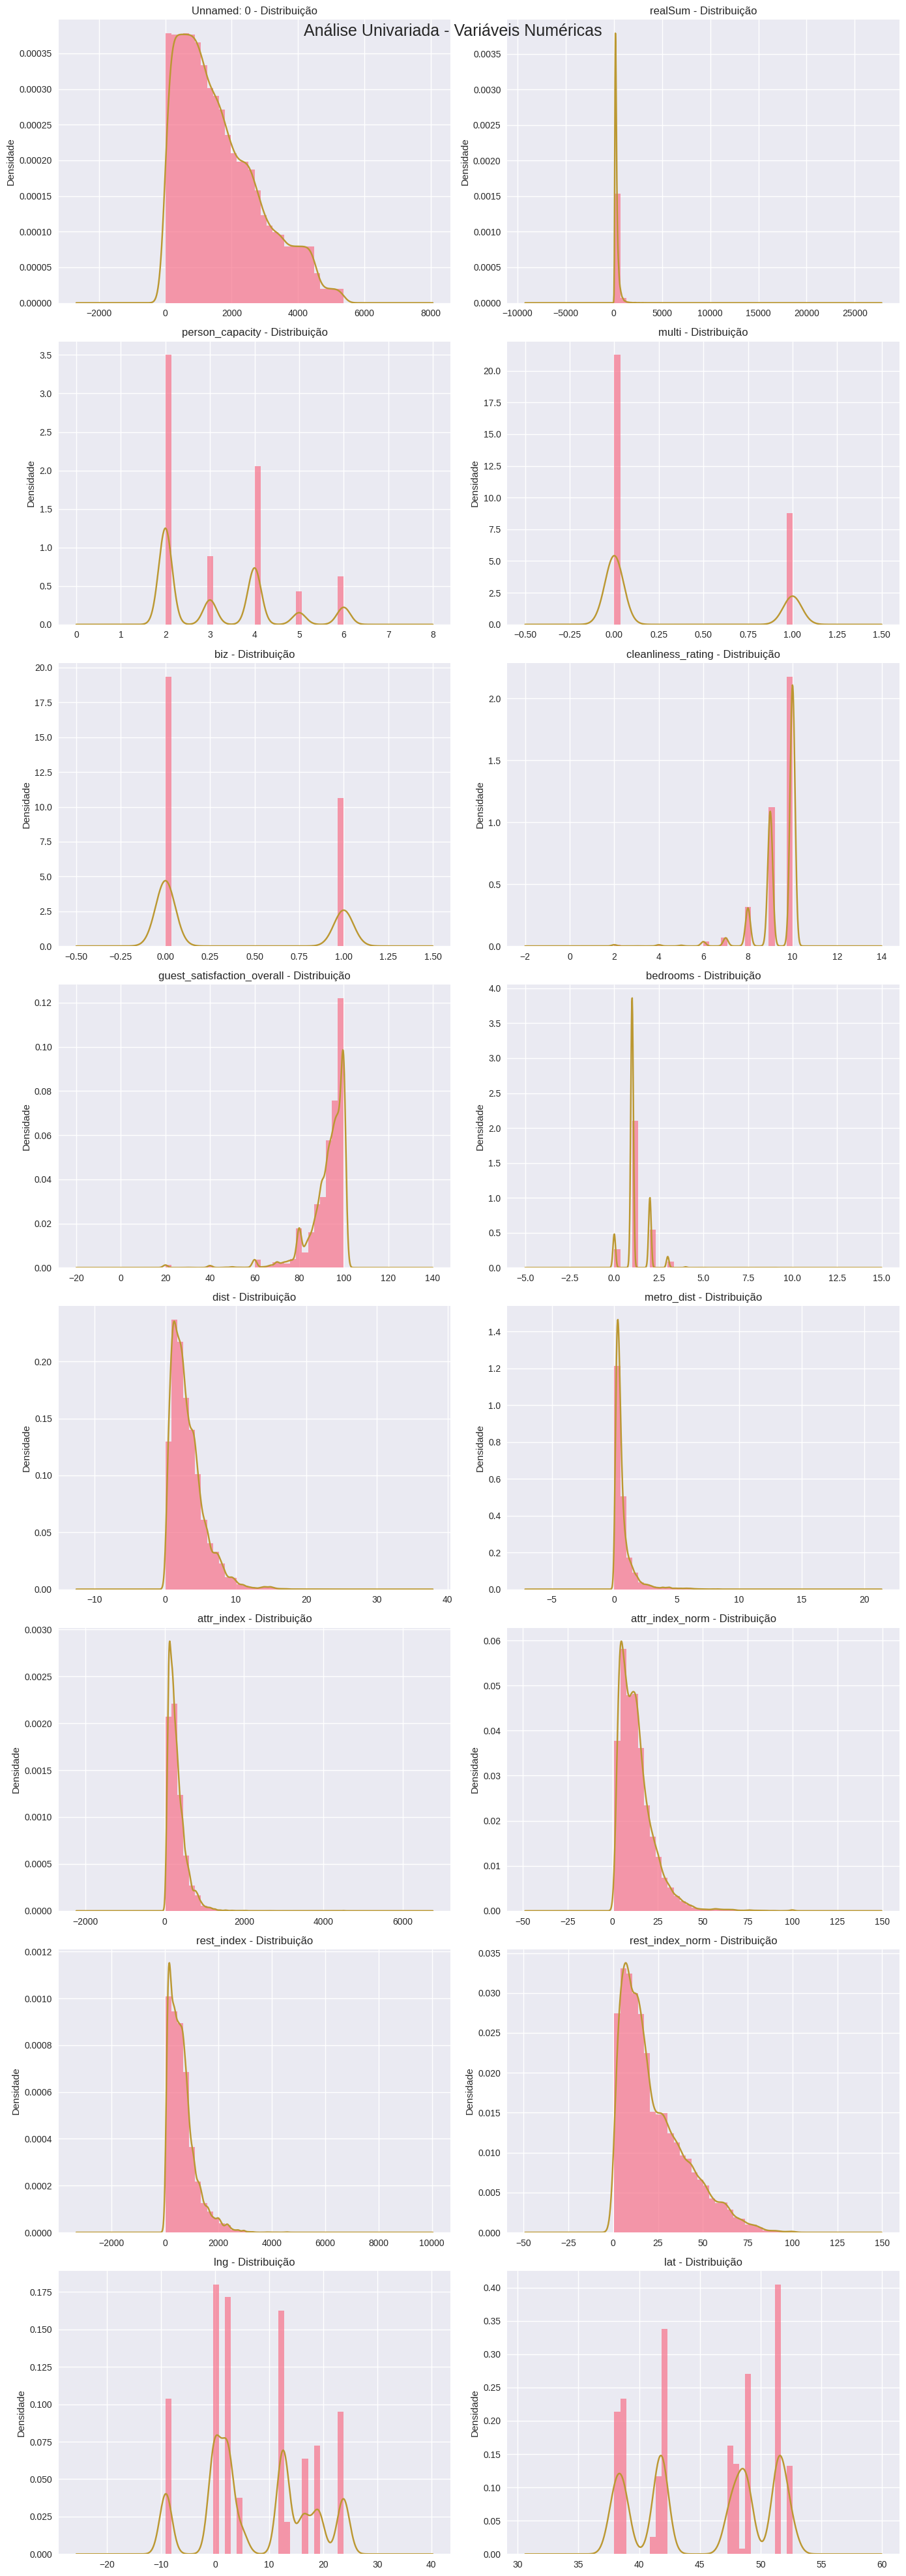

In [175]:
import math

# Total das variáveis numéricas
vars_to_plot = numeric_vars[:16]   # ou liste manualmente se preferir

cols = 2
rows = math.ceil(len(vars_to_plot) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('Análise Univariada - Variáveis Numéricas', fontsize=18)

axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    if var in df.columns:
        # Histograma
        ax.hist(df[var].dropna(), bins=30, alpha=0.7, density=True)

        # Linha de densidade (KDE)
        df[var].dropna().plot.density(ax=ax)

        ax.set_title(f'{var} - Distribuição')
        ax.set_ylabel('Densidade')

# Subplots vazios (caso existam)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


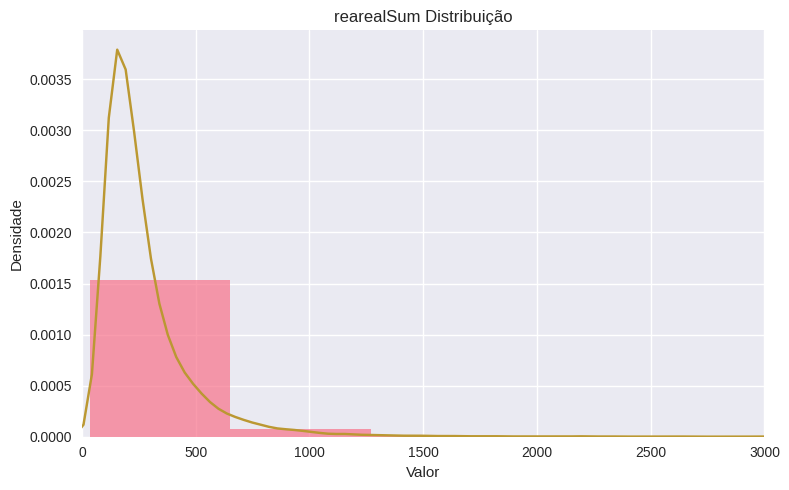

In [176]:
plt.figure(figsize=(8, 5))

plt.hist(df["realSum"].dropna(), bins=30, alpha=0.7, density=True)
df["realSum"].dropna().plot.density()

plt.title("rearealSum Distribuição")
plt.xlabel("Valor")
plt.ylabel("Densidade")

plt.xlim(0, 3000)   # escolha o valor ideal após observar o dataset

plt.tight_layout()
plt.show()


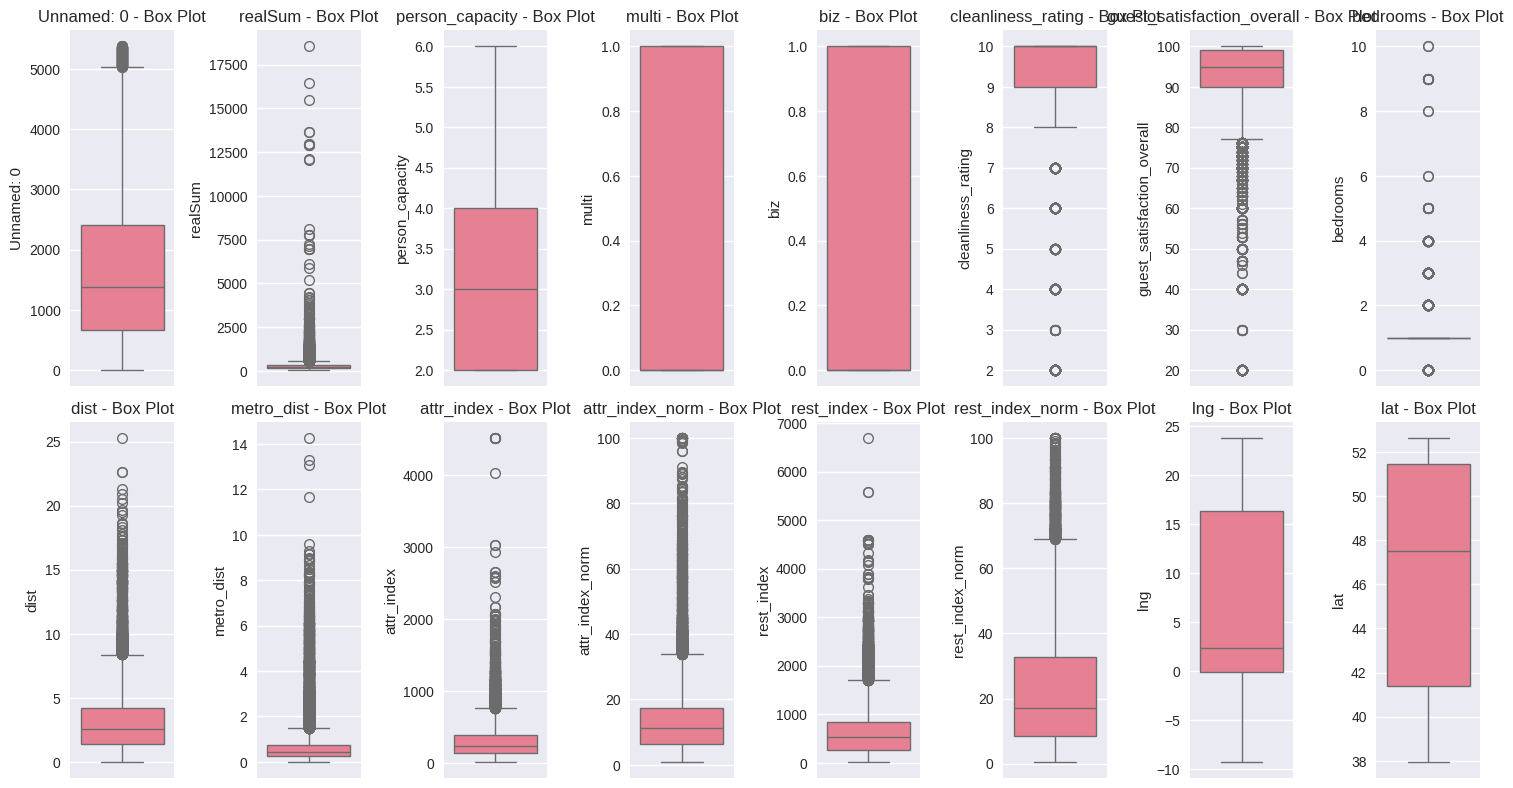

In [177]:
# Box plots para identificar outliers
plt.figure(figsize=(15, 8))
numeric_data = df[numeric_vars].select_dtypes(include=[np.number])
# Select only the first 6 numeric variables to plot
variables_to_plot = numeric_data.columns[:16]
for i, var in enumerate(variables_to_plot):
    plt.subplot(2, 8, i+1)
    sns.boxplot(y=df[var])
    plt.title(f'{var} - Box Plot')
plt.tight_layout()
plt.show()

In [178]:
# 2. ANÁLISE DE VARIÁVEIS CATEGÓRICAS
print("\n2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:")


2️⃣ ANÁLISE DE VARIÁVEIS CATEGÓRICAS:


In [179]:
# Análise de frequências
for var in categorical_vars:
    if var in df.columns:
        print(f"\n📊 {var.upper()}:")
        freq_table = df[var].value_counts()
        freq_percent = df[var].value_counts(normalize=True) * 100

        freq_df = pd.DataFrame({
            'Frequência': freq_table,
            'Percentual': freq_percent
        })
        print(freq_df.head(10))

        # Medida de concentração (Índice de Herfindahl)
        herfindahl = (freq_percent/100).pow(2).sum()
        print(f"  Índice de Herfindahl: {herfindahl:.3f}")
        print(f"  Entropia: {stats.entropy(freq_table):.3f}")


📊 ROOM_TYPE:
                 Frequência  Percentual
room_type                              
Entire home/apt       32174   63.808183
Private room          17918   35.535371
Shared room             331    0.656446
  Índice de Herfindahl: 0.533
  Entropia: 0.687

📊 ROOM_SHARED:
             Frequência  Percentual
room_shared                        
False             50092   99.343554
True                331    0.656446
  Índice de Herfindahl: 0.987
  Entropia: 0.040

📊 ROOM_PRIVATE:
              Frequência  Percentual
room_private                        
False              32505   64.464629
True               17918   35.535371
  Índice de Herfindahl: 0.542
  Entropia: 0.651

📊 HOST_IS_SUPERHOST:
                   Frequência  Percentual
host_is_superhost                        
False                   37533   74.436269
True                    12890   25.563731
  Índice de Herfindahl: 0.619
  Entropia: 0.568


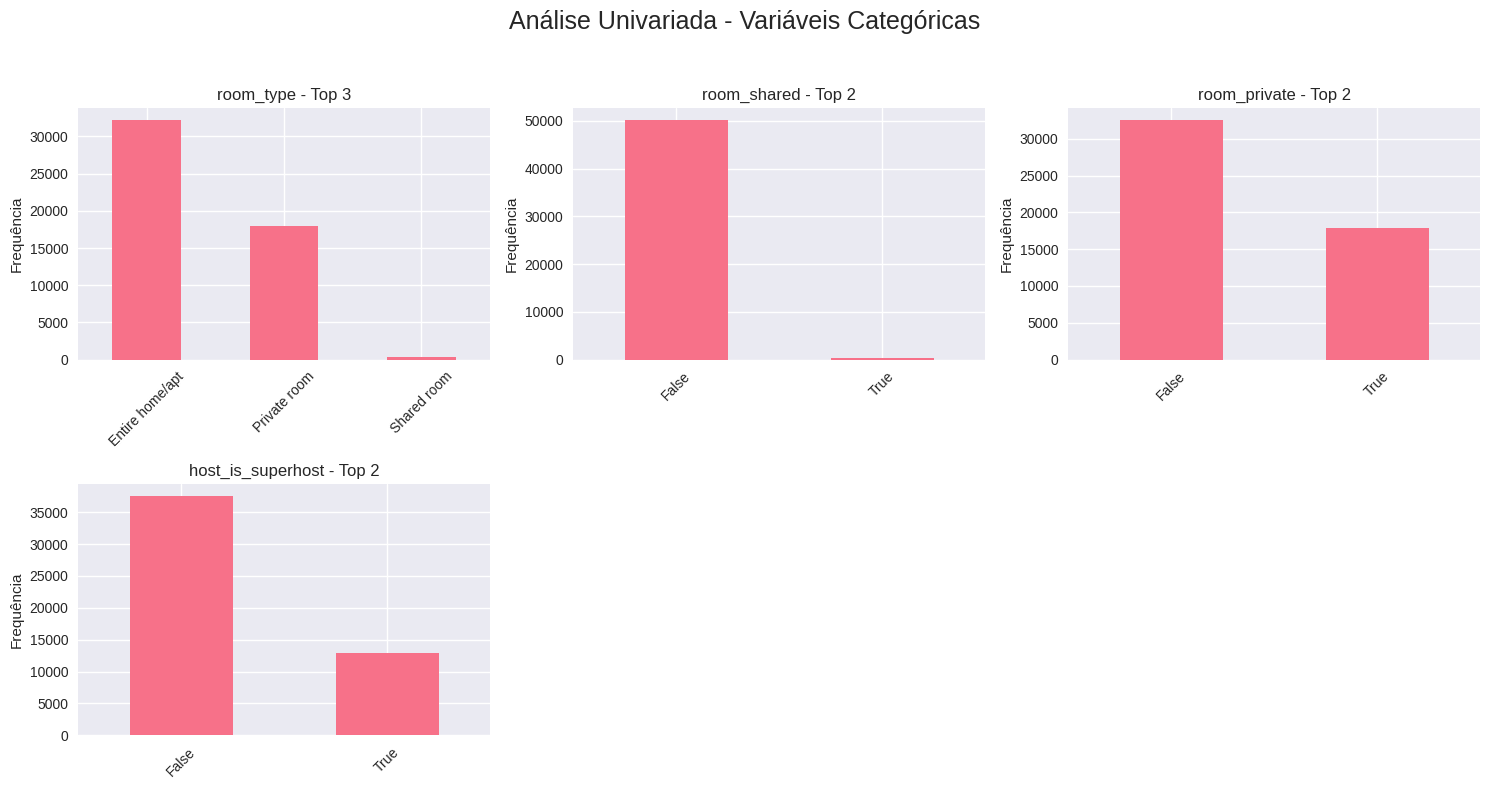

In [180]:
import math
import matplotlib.pyplot as plt

# lista de variáveis categóricas que você quer plotar
# (mantive sua variável original `categorical_vars`)
available_vars = [v for v in categorical_vars if v in df.columns]

n = len(available_vars)
if n == 0:
    print("Nenhuma variável categórica encontrada em df para plotar.")
else:
    # escolha do número de colunas (ajuste se quiser outro layout)
    max_cols = 3
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()  # facilita indexação mesmo quando rows*cols == 1

    fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=18)

    for idx, var in enumerate(available_vars):
        ax = axes[idx]

        # contagens completas e top (até 10)
        counts = df[var].value_counts()
        top_counts = counts.head(10)

        # escolha do tipo de gráfico:
        # Se a variável tiver <= 10 categorias, usa vertical; caso contrário usa horizontal (top 10)
        if counts.size <= 10:
            top_counts.plot(kind='bar', ax=ax)
            ax.tick_params(axis='x', rotation=45)
            ax.set_xlabel('')
            ax.set_ylabel('Frequência')
        else:
            top_counts.plot(kind='barh', ax=ax)
            ax.invert_yaxis()  # mostrar maior no topo
            ax.set_xlabel('Frequência')
            ax.set_ylabel('')

        ax.set_title(f'{var} - Top {min(10, counts.size)}')

    # esconder eixos sobrando (se houver)
    for j in range(n, rows * cols):
        axes[j].set_visible(False)

    # ajusta o layout deixando espaço para o suptitle
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


ANÁLISE EXPLORATÓRIA BIVARIADA

In [181]:
# 1. CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
print("\n1️⃣ MATRIZ DE CORRELAÇÃO:")


1️⃣ MATRIZ DE CORRELAÇÃO:


In [182]:
# Calcular matriz de correlação
correlation_matrix = df[numeric_vars].corr()

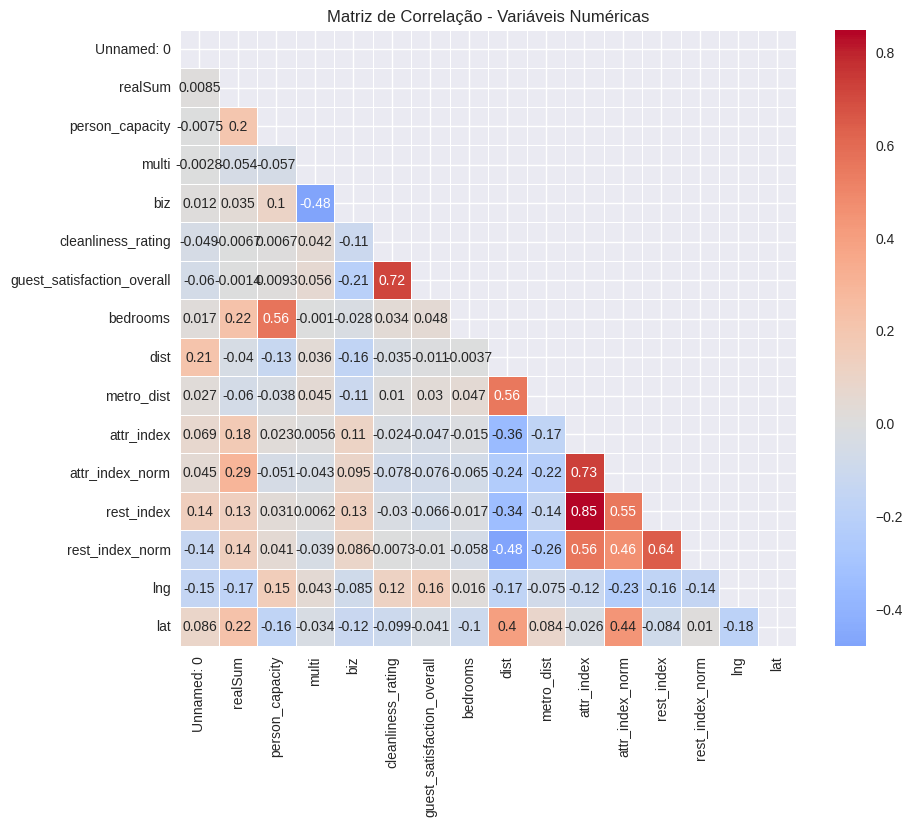

In [183]:
# Visualizar heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [184]:
# Identificar correlações fortes
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:  # Correlação forte
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

In [185]:
if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")


🔥 CORRELAÇÕES FORTES (|r| > 0.5):
  person_capacity ↔ bedrooms: 0.564
  cleanliness_rating ↔ guest_satisfaction_overall: 0.716
  dist ↔ metro_dist: 0.555
  attr_index ↔ attr_index_norm: 0.733
  attr_index ↔ rest_index: 0.848
  attr_index ↔ rest_index_norm: 0.560
  attr_index_norm ↔ rest_index: 0.548
  rest_index ↔ rest_index_norm: 0.641


In [186]:
# 2. ANÁLISE TARGET vs VARIÁVEIS NUMÉRICAS
print("\n2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:")


2️⃣ TARGET vs VARIÁVEIS NUMÉRICAS:


In [187]:
target_var = 'realSum'

In [188]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

corr = df[num_cols].corr()['realSum'].abs().sort_values(ascending=False)

top3 = corr.index[1:4].tolist()  # Ignora o próprio realSum
print("Top 3 variáveis mais correlacionadas:", top3)


Top 3 variáveis mais correlacionadas: ['attr_index_norm', 'lat', 'bedrooms']


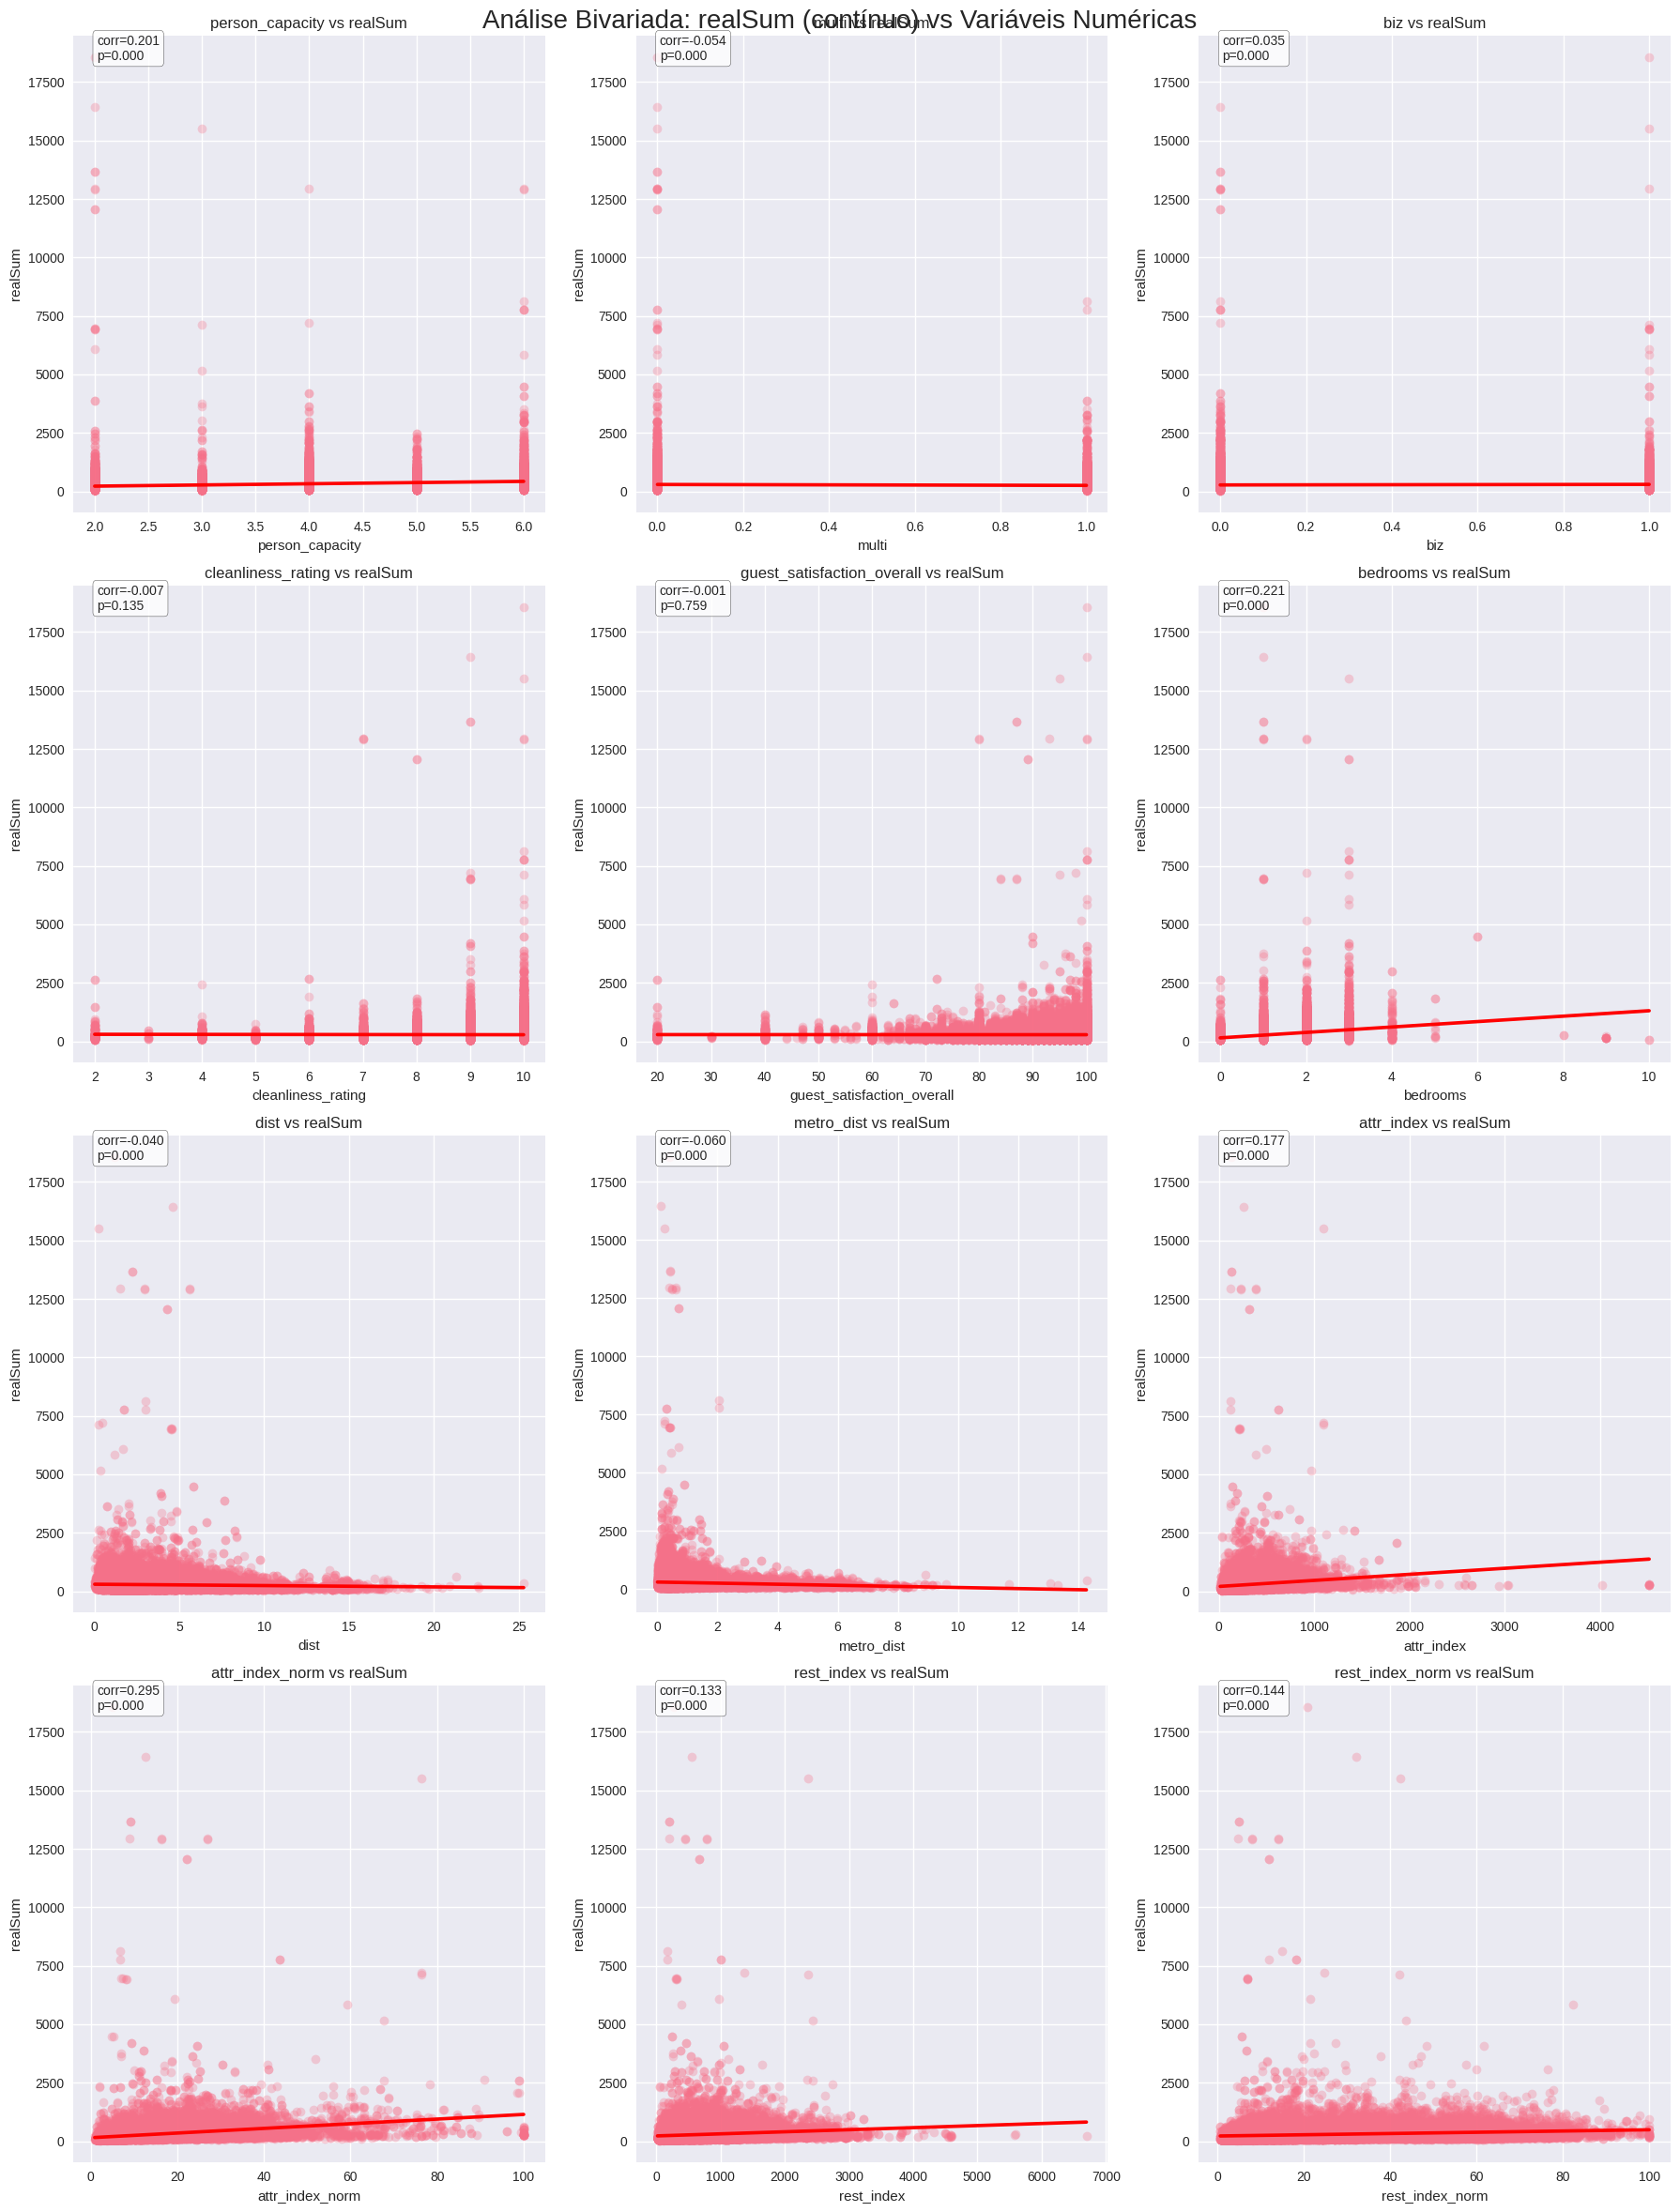

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import math

# Variáveis numéricas selecionadas para análise
numeric_for_analysis = [
    'person_capacity', 'multi', 'biz',
    'cleanliness_rating', 'guest_satisfaction_overall', 'bedrooms',
    'dist', 'metro_dist', 'attr_index', 'attr_index_norm',
    'rest_index', 'rest_index_norm'
]

n = len(numeric_for_analysis)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

fig.suptitle(f'Análise Bivariada: {target_var} (contínuo) vs Variáveis Numéricas', fontsize=20)

for i, var in enumerate(numeric_for_analysis):

    if var not in df.columns:
        continue

    ax = axes[i]

    # Scatter plot + regressão linear
    sns.regplot(
        data=df,
        x=var,
        y=target_var,
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'},
        ax=ax
    )
    
    ax.set_title(f'{var} vs {target_var}')

    # Correlação Pearson
    x = df[var].dropna()
    y = df[target_var].dropna()

    corr, pval = pearsonr(x, y)

    # Texto do p-value e correlação
    ax.text(
        0.05, 0.95,
        f'corr={corr:.3f}\np={pval:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

# Remover eixos vazios (caso sobrem)
for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [190]:
# 3. ANÁLISE TARGET vs VARIÁVEIS CATEGÓRICAS
print("\n3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:")


3️⃣ TARGET vs VARIÁVEIS CATEGÓRICAS:


In [191]:
df["realSum_log"] = np.log1p(df["realSum"])


In [196]:
categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
    "multi",
    "biz",
]

for var in categorical_for_analysis:
    print(f"\n===== {var.upper()} =====")
    summary = df.groupby(var)["realSum"].agg(["count", "mean", "median", "std"]).round(2)
    print(summary)



===== ROOM_TYPE =====
                 count    mean  median     std
room_type                                     
Entire home/apt  32174  323.91  247.59  351.84
Private room     17918  206.18  167.16  273.50
Shared room        331  143.56  122.10   81.33

===== ROOM_SHARED =====
             count    mean  median     std
room_shared                               
False        50092  281.80  212.95  330.83
True           331  143.56  122.10   81.33

===== ROOM_PRIVATE =====
              count    mean  median     std
room_private                               
False         32505  322.07  245.60  350.61
True          17918  206.18  167.16  273.50

===== HOST_IS_SUPERHOST =====
                   count    mean  median     std
host_is_superhost                               
False              37533  289.91  218.57  337.24
True               12890  254.62  197.08  306.44

===== MULTI =====
       count    mean  median     std
multi                               
0.0    35712  292.37  2

Variáveis válidas: ['room_type', 'room_shared', 'room_private', 'host_is_superhost', 'multi', 'biz']


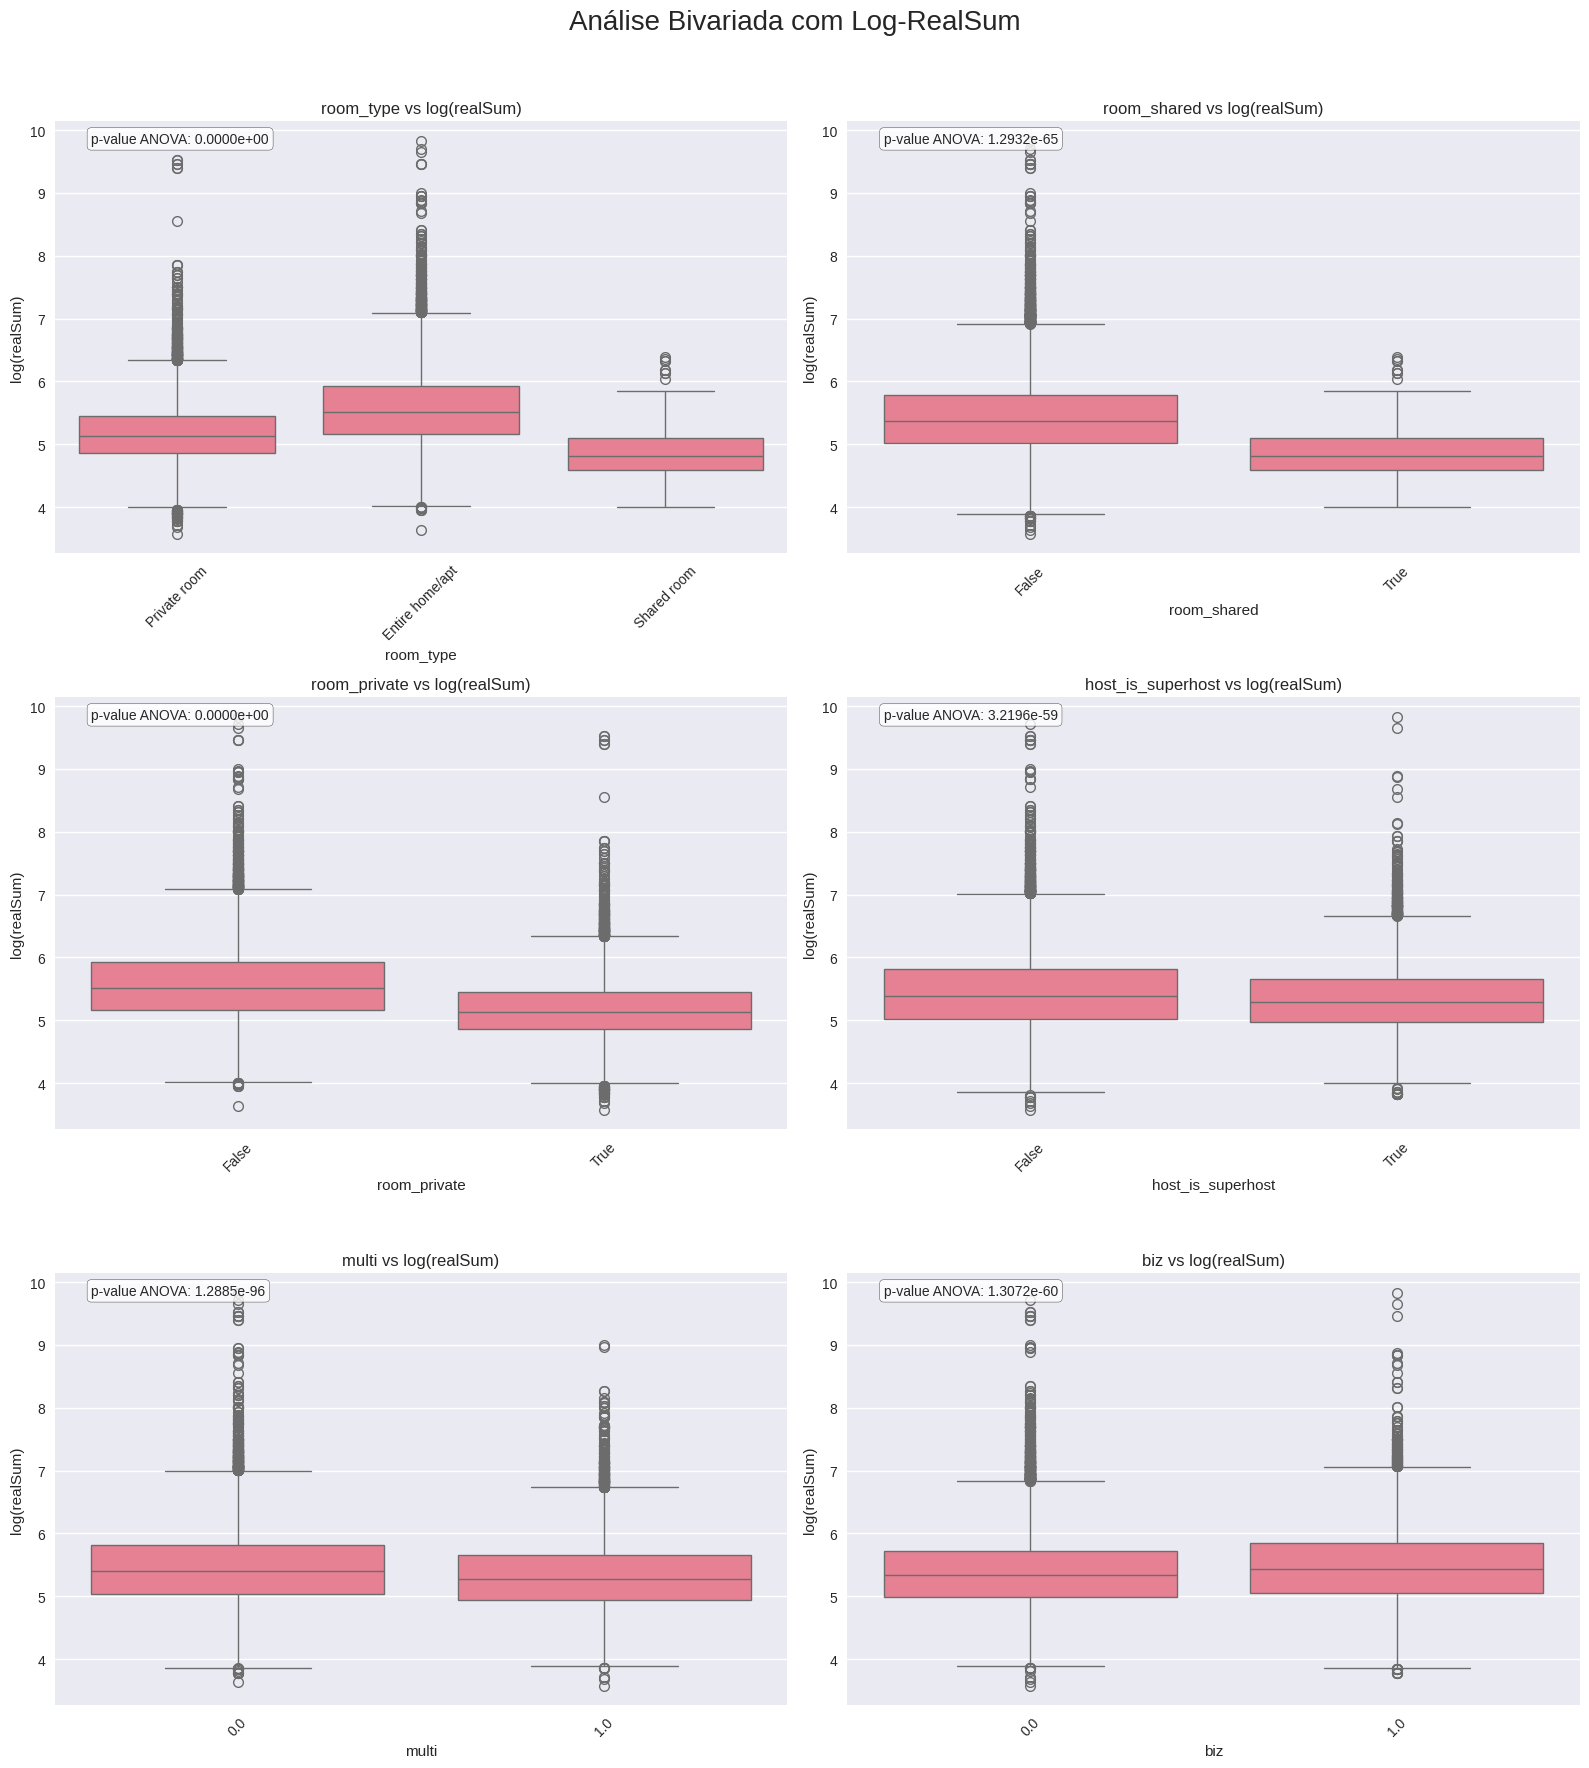

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import numpy as np


# ✅ Garantir valores válidos para log
df = df[df["realSum"] > 0].copy()
df["realSum_log"] = np.log1p(df["realSum"])

categorical_for_analysis = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
    "multi",
    "biz",
    "cidade",
    "tipo_dia"
]

# ✅ Filtrar apenas variáveis categóricas válidas
valid_categoricals = [
    var for var in categorical_for_analysis
    if var in df.columns and df[var].nunique() > 1
]

print("Variáveis válidas:", valid_categoricals)

# ✅ PROTEÇÃO CONTRA LISTA VAZIA
if len(valid_categoricals) == 0:
    raise ValueError("Nenhuma variável categórica válida para plotar.")

cols = 2
rows = math.ceil(len(valid_categoricals) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten()

fig.suptitle("Análise Bivariada com Log-RealSum", fontsize=20)

for i, var in enumerate(valid_categoricals):
    ax = axes[i]

    sns.boxplot(data=df, x=var, y="realSum_log", ax=ax)

    ax.set_title(f'{var} vs log(realSum)')
    ax.set_ylabel("log(realSum)")
    ax.tick_params(axis='x', rotation=45)

    # ✅ ANOVA segura
    groups = [df[df[var] == c]["realSum_log"].dropna() for c in df[var].dropna().unique()]

    if len(groups) >= 2:
        f_stat, p_value = stats.f_oneway(*groups)
        ax.text(
            0.05, 0.95,
            f'p-value ANOVA: {p_value:.4e}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

# ✅ Remover eixos vazios
for j in range(len(valid_categoricals), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
